In [1]:
# 06 · Population Health & ACO/VBC Lens
## **Lens:** ACO / Value-Based Care  
## Audience: ACO Medical Directors, Population Health Analysts, VBC Contract Managers

## | Section | Question |
## | 1 · Population Profile | Who is in this attributed panel, and what does their care cost? |
## | 2 · Administrative Leakage | Which segments carry the most billing friction? |
## | 3 · CARC as Clinical Signal | What does the denial pattern fingerprint tell us clinically? |
## | 4 · COPD + ER Utilization | Is disease management catching respiratory patients upstream? |
## | 5 · Auth in Complex Patients | Where is care coordination failing high-complexity populations? |

## **Tables used:** `claim_line`, `claim_header`, `remittance_835`, `denial_forensics`, `encounter_context`, `provider`  
## **Self-contained:** No cross-notebook dependencies.

In [4]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.db import get_connection

con = get_connection(read_only=True)
print("Setup complete.")

Setup complete.


In [6]:
# ── Segment Expression ───────────────────────────────────────────────────
# Currently: specialty-based attribution.
# To switch to ICD-10: replace with a CASE on cl.icd10_primary
# and ensure all queries include claim_line cl in the FROM clause.
SEGMENT_EXPR = "p.specialty"

SEGMENT_COLORS = {
    'Oncology':           '#e63946',
    'Emergency Medicine': '#f4a261',
    'Behavioral Health':  '#8338ec',
    'Radiology':          '#457b9d',
    'Internal Medicine':  '#2a9d8f',
}

print("Setup complete.")
print("Segments:", con.execute(
    "SELECT DISTINCT specialty FROM provider ORDER BY specialty"
).fetchall())

Setup complete.
Segments: [('Behavioral Health',), ('Emergency Medicine',), ('Internal Medicine',), ('Oncology',), ('Radiology',)]


------
#### Chapter 1 · Population Profile
###### Question: Who is in this attributed panel, and what does their care cost?

###### Specialty-level cost profile establishes the panel composition before any leakage analysis. The billed amount per encounter reflects the intensity of care delivered in each setting — Oncology and Emergency Medicine carry the highest per-encounter costs, which means administrative failures there have disproportionate financial consequence.

Population Profile by Specialty Segment

   patient_segment  unique_patients  total_claim_lines  total_billed  avg_billed_per_line  avg_billed_per_patient
          Oncology             4759              13755   57758679.20              4199.10                12136.73
Emergency Medicine             4866              13994   17434945.18              1245.89                 3583.01
         Radiology             4761              13760    9044776.28               657.32                 1899.76
 Internal Medicine             4950              14236    2569886.55               180.52                  519.17
 Behavioral Health             4827              13829    1949031.85               140.94                  403.78


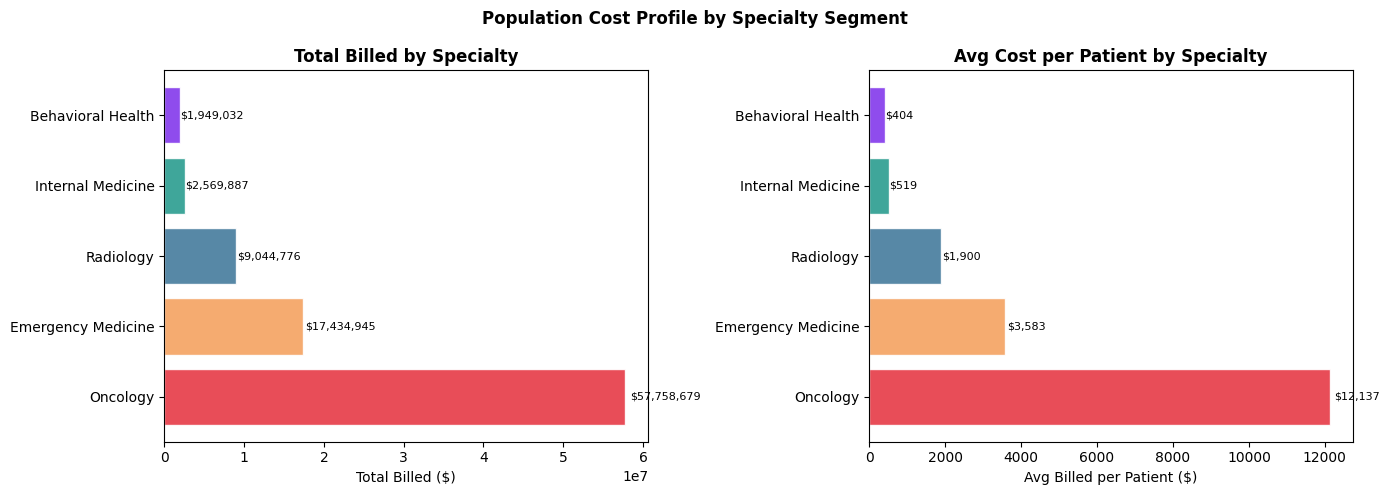

In [17]:
pop_profile = con.execute(f"""
    SELECT
        {SEGMENT_EXPR}                                                    AS patient_segment,
        COUNT(DISTINCT ch.patient_id)                                     AS unique_patients,
        COUNT(cl.claim_line_id)                                           AS total_claim_lines,
        ROUND(SUM(cl.billed_amount), 2)                                   AS total_billed,
        ROUND(AVG(cl.billed_amount), 2)                                   AS avg_billed_per_line,
        ROUND(SUM(cl.billed_amount)
              / NULLIF(COUNT(DISTINCT ch.patient_id), 0), 2)              AS avg_billed_per_patient
    FROM claim_line cl
    JOIN claim_header ch ON cl.claim_id = ch.claim_id
    JOIN provider p      ON ch.provider_id = p.provider_id
    GROUP BY patient_segment
    ORDER BY total_billed DESC
""").df()

print("Population Profile by Specialty Segment\n")
print(pop_profile.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [SEGMENT_COLORS.get(s, "#adb5bd") for s in pop_profile["patient_segment"]]

bars1 = ax1.barh(pop_profile["patient_segment"], pop_profile["total_billed"],
                 color=colors, edgecolor="white", alpha=0.9)
for bar, val in zip(bars1, pop_profile["total_billed"]):
    ax1.text(val * 1.01, bar.get_y() + bar.get_height()/2,
             f"${val:,.0f}", va="center", fontsize=8)
ax1.set_xlabel("Total Billed ($)")
ax1.set_title("Total Billed by Specialty", fontweight="bold")

bars2 = ax2.barh(pop_profile["patient_segment"], pop_profile["avg_billed_per_patient"],
                 color=colors, edgecolor="white", alpha=0.9)
for bar, val in zip(bars2, pop_profile["avg_billed_per_patient"]):
    ax2.text(val * 1.01, bar.get_y() + bar.get_height()/2,
             f"${val:,.0f}", va="center", fontsize=8)
ax2.set_xlabel("Avg Billed per Patient ($)")
ax2.set_title("Avg Cost per Patient by Specialty", fontweight="bold")

plt.suptitle("Population Cost Profile by Specialty Segment", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

----------
#### Chapter 2 · Administrative Leakage by Segment

###### Question: Which patient segments carry the most billing friction?

###### Denial rate alone is a blunt instrument — a segment with 5% denial rate where 500K is billed hurts more than 20% on $50K. This section pairs denial rate with absolute dollar leakage per segment, then plots cost of care against administrative friction.


Administrative Leakage by Specialty Segment

   patient_segment  total_lines  denied_lines  denial_rate_pct  total_denied_dollars  total_billed  leakage_rate_pct
          Oncology        13755        1872.0             13.6            7909245.58   57758679.20              13.7
Emergency Medicine        13994        2230.0             15.9            2807019.30   17434945.18              16.1
         Radiology        13760        1636.0             11.9            1064239.74    9044776.28              11.8
 Behavioral Health        13829        2897.0             20.9             407240.59    1949031.85              20.9
 Internal Medicine        14236        1454.0             10.2             260030.37    2569886.55              10.1


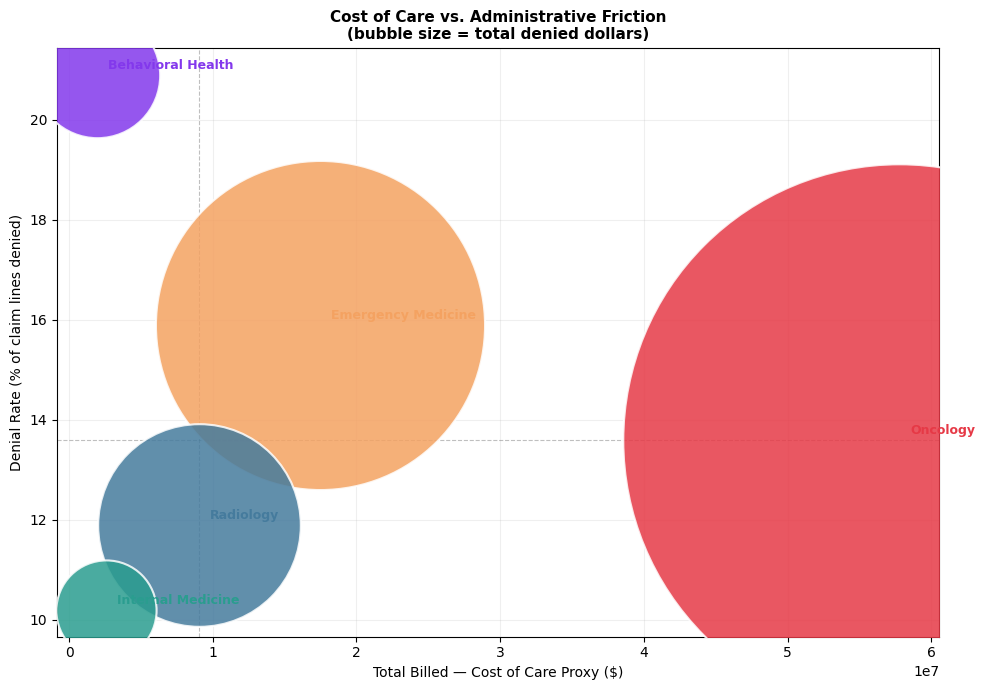

In [18]:
leakage = con.execute(f"""
    SELECT
        {SEGMENT_EXPR}                                                    AS patient_segment,
        COUNT(cl.claim_line_id)                                           AS total_lines,
        SUM(CASE WHEN r.paid_amount = 0
                  AND r.carc_code NOT IN ('CO-45', 'PR-1')
                 THEN 1 ELSE 0 END)                                       AS denied_lines,
        ROUND(100.0 * SUM(CASE WHEN r.paid_amount = 0
                               AND r.carc_code NOT IN ('CO-45', 'PR-1')
                               THEN 1 ELSE 0 END)
              / NULLIF(COUNT(cl.claim_line_id), 0), 1)                    AS denial_rate_pct,
        ROUND(SUM(CASE WHEN df.dollars_at_risk IS NOT NULL
                       THEN df.dollars_at_risk ELSE 0 END), 2)            AS total_denied_dollars,
        ROUND(SUM(cl.billed_amount), 2)                                   AS total_billed,
        ROUND(100.0 * SUM(CASE WHEN df.dollars_at_risk IS NOT NULL
                               THEN df.dollars_at_risk ELSE 0 END)
              / NULLIF(SUM(cl.billed_amount), 0), 1)                      AS leakage_rate_pct
    FROM claim_line cl
    JOIN claim_header ch          ON cl.claim_id = ch.claim_id
    JOIN remittance_835 r         ON cl.claim_line_id = r.claim_line_id
    LEFT JOIN denial_forensics df ON r.claim_line_id = df.claim_line_id
    JOIN provider p               ON ch.provider_id = p.provider_id
    GROUP BY patient_segment
    ORDER BY total_denied_dollars DESC
""").df()

print("Administrative Leakage by Specialty Segment\n")
print(leakage.to_string(index=False))

# Cost vs friction bubble chart
fig, ax = plt.subplots(figsize=(10, 7))
for _, row in leakage.iterrows():
    seg   = row["patient_segment"]
    x     = row["total_billed"]
    y     = row["denial_rate_pct"]
    size  = max(80, row["total_denied_dollars"] / 50)
    color = SEGMENT_COLORS.get(seg, "#adb5bd")
    ax.scatter(x, y, s=size, color=color, alpha=0.85,
               edgecolors="white", linewidth=1.5, zorder=3)
    ax.annotate(seg, (x, y), textcoords="offset points",
                xytext=(8, 4), fontsize=9, fontweight="bold", color=color)

ax.axvline(leakage["total_billed"].median(), color="gray",
           linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(leakage["denial_rate_pct"].median(), color="gray",
           linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Total Billed — Cost of Care Proxy ($)", fontsize=10)
ax.set_ylabel("Denial Rate (% of claim lines denied)", fontsize=10)
ax.set_title("Cost of Care vs. Administrative Friction\n"
             "(bubble size = total denied dollars)",
             fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

##### What this tells us

######  The upper-right quadrant — high cost AND high denial rate — is where administrative friction compounds clinical complexity. An Oncology or Emergency encounter denied costs multiples more than the same denial rate on a lower-intensity Internal Medicine encounter.
###### The lower-right quadrant — high volume or cost, low denial rate — is the performance benchmark: same revenue cycle infrastructure, better results. Understanding what makes that specialty's billing process cleaner is as analytically useful as understanding what makes the high-friction ones messy.

--------
#### Chapter 3 · CARC Mix as Clinical Signal

###### Question: What does the denial fingerprint tell us about care delivery by specialty?
###### CARC codes are instructions for billing staff. Read by a population health analyst, they're a diagnostic — each concentration pointing at a different failure in the care delivery process. The composition of denials per specialty is more informative than the volume.

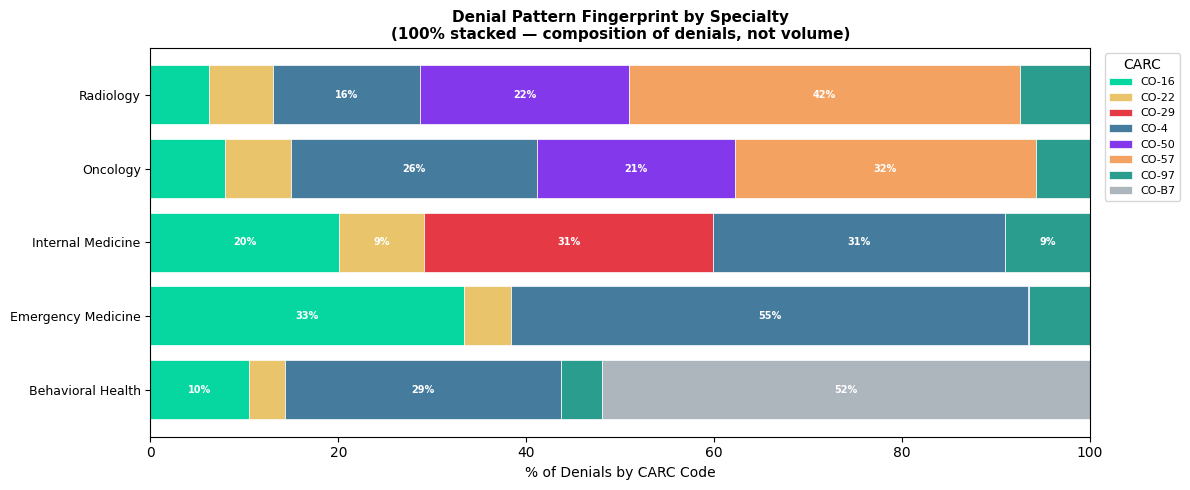


Raw CARC mix by specialty:
carc_code           CO-16  CO-22  CO-29  CO-4  CO-50  CO-57  CO-97  CO-B7
patient_segment                                                          
Behavioral Health    10.5    3.9    0.0  29.3    0.0    0.0    4.4   52.0
Emergency Medicine   33.4    4.9    0.0  55.1    0.1    0.0    6.5    0.0
Internal Medicine    20.1    9.0   30.8  31.0    0.0    0.0    9.1    0.0
Oncology              7.9    7.0    0.0  26.2   21.0   32.1    5.8    0.0
Radiology             6.2    6.8    0.0  15.7   22.2   41.6    7.5    0.0


In [21]:
carc_mix = con.execute(f"""
    SELECT
        {SEGMENT_EXPR}    AS patient_segment,
        df.carc_code,
        COUNT(*)          AS denial_count
    FROM denial_forensics df
    JOIN remittance_835 r  ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch   ON r.claim_id = ch.claim_id
    JOIN provider p        ON ch.provider_id = p.provider_id
    GROUP BY patient_segment, df.carc_code
    ORDER BY patient_segment, denial_count DESC
""").df()

pivot = carc_mix.pivot_table(
    index="patient_segment", columns="carc_code",
    values="denial_count", aggfunc="sum"
).fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

carc_colors = {
    'CO-29': '#e63946', 'CO-57': '#f4a261', 'CO-97': '#2a9d8f',
    'CO-4':  '#457b9d', 'CO-50': '#8338ec', 'CO-22': '#e9c46a',
    'CO-16': '#06d6a0', 'CO-B7': '#adb5bd',
}

fig, ax = plt.subplots(figsize=(12, 5))
left = np.zeros(len(pivot_pct))
y_pos = range(len(pivot_pct))

for carc in pivot_pct.columns:
    vals  = pivot_pct[carc].values
    color = carc_colors.get(carc, "#cccccc")
    ax.barh(list(y_pos), vals, left=left, color=color,
            edgecolor="white", linewidth=0.5, label=carc)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 8:
            ax.text(l + v/2, i, f"{v:.0f}%",
                    ha="center", va="center", fontsize=7,
                    color="white", fontweight="bold")
    left += vals

ax.set_yticks(list(y_pos))
ax.set_yticklabels(pivot_pct.index, fontsize=9)
ax.set_xlabel("% of Denials by CARC Code")
ax.set_title("Denial Pattern Fingerprint by Specialty\n"
             "(100% stacked — composition of denials, not volume)",
             fontsize=11, fontweight="bold")
ax.legend(title="CARC", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

print("\nRaw CARC mix by specialty:")
print(pivot_pct.round(1).to_string())

##### What this tells us — the clinical translation

###### **CO-57 concentration in Radiology and Oncology:**  
###### Prior auth misses in imaging-intensive and cancer care aren't a scheduling staff problem. They signal that care coordinators aren't embedded in the ordering workflow — procedure urgency is outpacing the administrative authorization process. The intervention is a care coordination model change, not a billing training.

###### **CO-50 (medical necessity) in Oncology:**  
###### When a payer denies medical necessity on an oncology claim where auth was obtained, it means the clinical documentation submitted with the auth request didn't meet the payer's criteria. This is a CDI (clinical documentation improvement) gap — not a billing department failure.

###### **CO-4 concentration in Emergency Medicine:**  
###### Coding errors in acute, unplanned care are expected — ER encounters are coded under time pressure with incomplete documentation. High CO-4 rate in EM signals that CDI and coder support are needed at the point of acute encounter, not retroactively in the billing queue.

###### **CO-B7 concentration in Behavioral Health:**  
###### Credentialing lapses in BH point at a provider network stability problem. High turnover in BH means re-credentialing cycles run behind active care delivery. The ACO signal: network adequacy for behavioral health is fragile, and that fragility has a direct dollar cost.

###### **CO-29 in Internal Medicine:**  
###### Timely filing failures are a charge capture process problem, not a clinical one. But in a chronic disease management context, if internal medicine encounters are being submitted late, it may reflect an overburdened billing workflow that doesn't have bandwidth to manage high-volume, lower-intensity encounters promptly.

-------
#### Chapter 4 · Emergency Medicine Utilization — Reactive Care as a System Signal

###### Question: Is acute care filling a gap that managed care should be covering?
###### Emergency Medicine represents unplanned, reactive care delivered under time pressure — not necessarily the most expensive per encounter, but the setting where care coordination upstream has already failed. When EM utilization is high in an attributed panel, it signals that preventable decompensations aren't being caught earlier in a lower-intensity setting.

EM vs. Planned Care — Cost and Denial Comparison

         specialty         care_type  total_lines  unique_patients  avg_billed_per_line  total_billed  denied_lines  denial_rate_pct  denied_dollars
          Oncology Planned / Managed        13755             4759              4199.10   57758679.20        1872.0             13.6      7909245.58
         Radiology Planned / Managed        13760             4761               657.32    9044776.28        1636.0             11.9      1064239.74
 Internal Medicine Planned / Managed        14236             4950               180.52    2569886.55        1454.0             10.2       260030.37
 Behavioral Health Planned / Managed        13829             4827               140.94    1949031.85        2897.0             20.9       407240.59
Emergency Medicine  Reactive / Acute        13994             4866              1245.89   17434945.18        2230.0             15.9      2807019.30


/var/folders/qx/h9hpb4v922v25zpnvvtqkdv40000gn/T/ipykernel_20955/4015450955.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(em_vs_planned["specialty"], rotation=20, ha="right")
/var/folders/qx/h9hpb4v922v25zpnvvtqkdv40000gn/T/ipykernel_20955/4015450955.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(em_vs_planned["specialty"], rotation=20, ha="right")


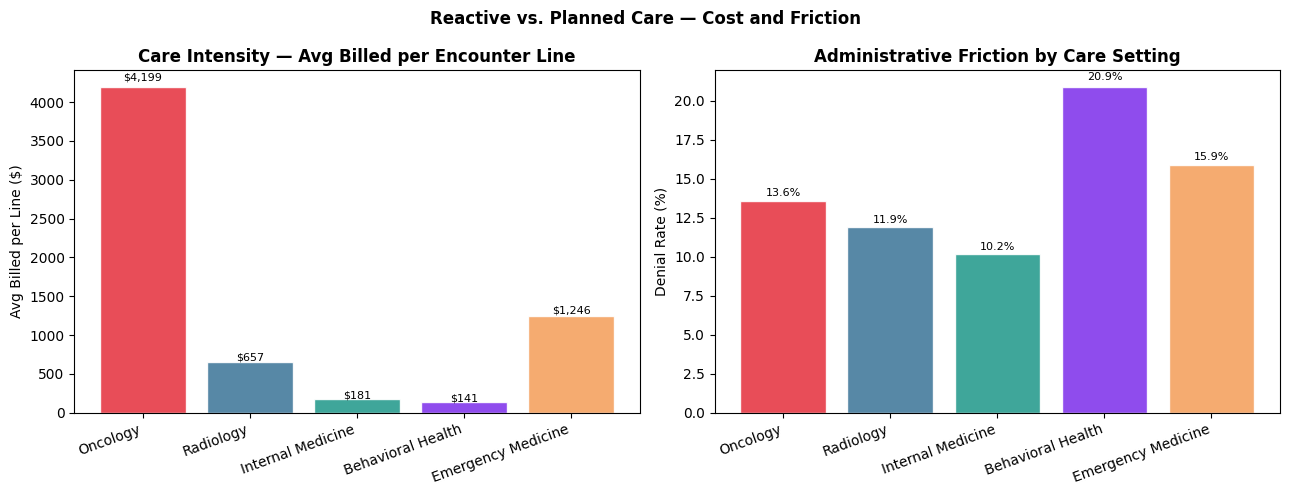

In [22]:
# EM vs. planned care: cost and denial pattern comparison
em_vs_planned = con.execute("""
    SELECT
        p.specialty,
        CASE WHEN p.specialty = 'Emergency Medicine'
             THEN 'Reactive / Acute' ELSE 'Planned / Managed' END    AS care_type,
        COUNT(cl.claim_line_id)                                       AS total_lines,
        COUNT(DISTINCT ch.patient_id)                                 AS unique_patients,
        ROUND(AVG(cl.billed_amount), 2)                               AS avg_billed_per_line,
        ROUND(SUM(cl.billed_amount), 2)                               AS total_billed,
        SUM(CASE WHEN r.paid_amount = 0
                  AND r.carc_code NOT IN ('CO-45', 'PR-1')
                 THEN 1 ELSE 0 END)                                   AS denied_lines,
        ROUND(100.0 * SUM(CASE WHEN r.paid_amount = 0
                               AND r.carc_code NOT IN ('CO-45', 'PR-1')
                               THEN 1 ELSE 0 END)
              / NULLIF(COUNT(cl.claim_line_id), 0), 1)                AS denial_rate_pct,
        ROUND(SUM(CASE WHEN df.dollars_at_risk IS NOT NULL
                       THEN df.dollars_at_risk ELSE 0 END), 2)        AS denied_dollars
    FROM claim_line cl
    JOIN claim_header ch          ON cl.claim_id = ch.claim_id
    JOIN remittance_835 r         ON cl.claim_line_id = r.claim_line_id
    LEFT JOIN denial_forensics df ON r.claim_line_id = df.claim_line_id
    JOIN provider p               ON ch.provider_id = p.provider_id
    GROUP BY p.specialty, care_type
    ORDER BY care_type, avg_billed_per_line DESC
""").df()

print("EM vs. Planned Care — Cost and Denial Comparison\n")
print(em_vs_planned.to_string(index=False))

# Cost differential bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = [SEGMENT_COLORS.get(s, "#adb5bd") for s in em_vs_planned["specialty"]]
bars1 = ax1.bar(em_vs_planned["specialty"], em_vs_planned["avg_billed_per_line"],
                color=colors, edgecolor="white", alpha=0.9)
for bar, val in zip(bars1, em_vs_planned["avg_billed_per_line"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val * 1.02,
             f"${val:,.0f}", ha="center", fontsize=8)
ax1.set_ylabel("Avg Billed per Line ($)")
ax1.set_title("Care Intensity — Avg Billed per Encounter Line", fontweight="bold")
ax1.set_xticklabels(em_vs_planned["specialty"], rotation=20, ha="right")

bars2 = ax2.bar(em_vs_planned["specialty"], em_vs_planned["denial_rate_pct"],
                color=colors, edgecolor="white", alpha=0.9)
for bar, val in zip(bars2, em_vs_planned["denial_rate_pct"]):
    ax2.text(bar.get_x() + bar.get_width()/2, val * 1.02,
             f"{val:.1f}%", ha="center", fontsize=8)
ax2.set_ylabel("Denial Rate (%)")
ax2.set_title("Administrative Friction by Care Setting", fontweight="bold")
ax2.set_xticklabels(em_vs_planned["specialty"], rotation=20, ha="right")

plt.suptitle("Reactive vs. Planned Care — Cost and Friction",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

##### What this tells us

###### Emergency Medicine carries the highest average billed amount per encounter — reflecting care delivered under urgency, without the efficiency of planned care coordination. If EM also shows elevated denial rates, both signals compound: the patient arrived in the wrong setting AND the encounter generated additional billing friction.

###### In a well-managed ACO, the goal isn't to reduce EM encounters for genuine emergencies — it's to ensure that patients who *could* have been managed in a lower-intensity setting had access to that pathway before they decompensated. COPD exacerbations, uncontrolled diabetes, behavioral health crises — these present in the ER when disease management upstream failed. The EM denial pattern (CO-4 coding pressure, CO-16 eligibility gaps) is the administrative signature of that failure.

###### The contracting implication: An ACO with disproportionate EM utilization relative to attributed population risk score is spending the wrong dollars in the wrong setting — and generating avoidable billing friction on top.

-------
#### Chatper 5 · Prior Authorization by Specialty — Care Coordination Signal

###### Question: Where is care coordination failing high-complexity care delivery?

###### Auth obtain rates are typically tracked as a billing metric. Tracked by specialty, they become a care coordination quality metric. A low obtain rate in Radiology or Oncology doesn't mean the scheduler is undertrained — it may mean no one owns the auth pipeline in those workflows before care is delivered.

Prior Auth Pattern by Specialty Segment

   patient_segment  total_encounters  auth_required  auth_obtained  obtain_rate_pct  retro_auth_count  retro_auth_rate_pct
         Radiology              4936         3174.0         2170.0             68.4             490.0                 22.6
          Oncology              4928         3442.0         2580.0             75.0             387.0                 15.0
Emergency Medicine              5020           11.0           10.0             90.9               0.0                  0.0
 Behavioral Health              4987            8.0            8.0            100.0               0.0                  0.0
 Internal Medicine              5129            8.0            8.0            100.0               0.0                  0.0


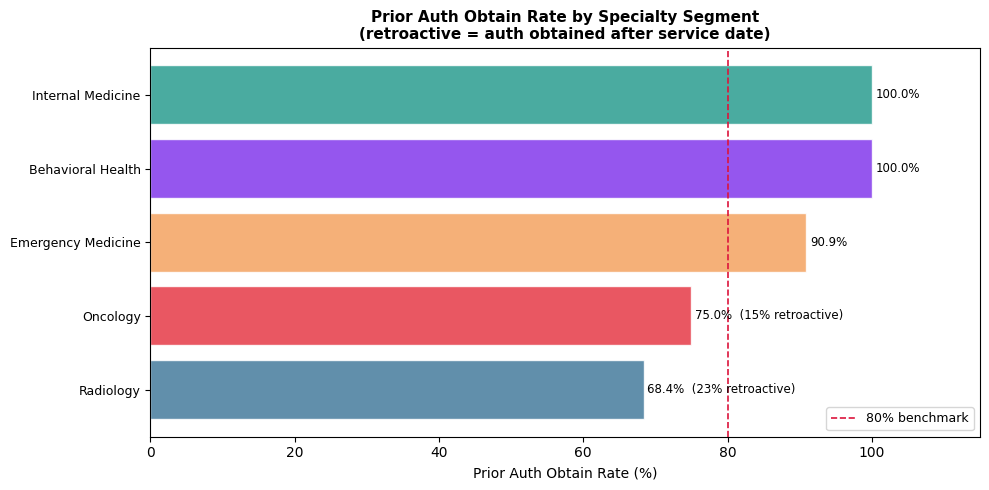

In [23]:
auth_by_specialty = con.execute(f"""
    SELECT
        {SEGMENT_EXPR}                                                        AS patient_segment,
        COUNT(ec.encounter_id)                                                AS total_encounters,
        SUM(CASE WHEN ec.prior_auth_required = TRUE THEN 1 ELSE 0 END)        AS auth_required,
        SUM(CASE WHEN ec.prior_auth_required = TRUE
                  AND ec.prior_auth_obtained = TRUE THEN 1 ELSE 0 END)        AS auth_obtained,
        ROUND(100.0 * SUM(CASE WHEN ec.prior_auth_required = TRUE
                               AND ec.prior_auth_obtained = TRUE THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN ec.prior_auth_required = TRUE
                               THEN 1 ELSE 0 END), 0), 1)                    AS obtain_rate_pct,
        SUM(CASE WHEN ec.prior_auth_required = TRUE
                  AND ec.prior_auth_obtained = TRUE
                  AND ec.auth_request_date > ec.date_of_service
                 THEN 1 ELSE 0 END)                                           AS retro_auth_count,
        ROUND(100.0 * SUM(CASE WHEN ec.prior_auth_required = TRUE
                               AND ec.prior_auth_obtained = TRUE
                               AND ec.auth_request_date > ec.date_of_service
                               THEN 1 ELSE 0 END)
              / NULLIF(SUM(CASE WHEN ec.prior_auth_required = TRUE
                               AND ec.prior_auth_obtained = TRUE
                               THEN 1 ELSE 0 END), 0), 1)                    AS retro_auth_rate_pct
    FROM encounter_context ec
    JOIN claim_header ch ON ec.claim_id = ch.claim_id
    JOIN provider p      ON ch.provider_id = p.provider_id
    GROUP BY patient_segment
    HAVING SUM(CASE WHEN ec.prior_auth_required = TRUE THEN 1 ELSE 0 END) > 0
    ORDER BY obtain_rate_pct ASC
""").df()

print("Prior Auth Pattern by Specialty Segment\n")
print(auth_by_specialty.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(auth_by_specialty))
colors = [SEGMENT_COLORS.get(s, "#adb5bd") for s in auth_by_specialty["patient_segment"]]

ax.barh(list(y), auth_by_specialty["obtain_rate_pct"],
        color=colors, edgecolor="white", alpha=0.85)
ax.axvline(80, color="crimson", linestyle="--", linewidth=1.2, label="80% benchmark")

for i, (rate, retro) in enumerate(zip(
    auth_by_specialty["obtain_rate_pct"],
    auth_by_specialty["retro_auth_rate_pct"].fillna(0)
)):
    label = f"{rate:.1f}%"
    if retro > 0:
        label += f"  ({retro:.0f}% retroactive)"
    ax.text(rate + 0.5, i, label, va="center", fontsize=8.5)

ax.set_yticks(list(y))
ax.set_yticklabels(auth_by_specialty["patient_segment"], fontsize=9)
ax.set_xlabel("Prior Auth Obtain Rate (%)")
ax.set_title("Prior Auth Obtain Rate by Specialty Segment\n"
             "(retroactive = auth obtained after service date)",
             fontsize=11, fontweight="bold")
ax.set_xlim(0, 115)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

##### What this tells us

###### Obtain rate below 80% in any specialty signals a systemic gap — not individual staff error. In a well-functioning ACO, high-complexity specialties have dedicated care coordinators whose explicit job includes managing the authorization pipeline ahead of scheduled care.

###### **Retroactive auth rate** is the leading indicator that the auth process is running behind care delivery. These encounters didn't generate CO-57 denials this period — but they represent process fragility. If a payer tightens retroactive auth policy, these convert to denials without any change in clinical behavior.

##### **The ACO framing:**  
###### A low auth obtain rate in Radiology or Oncology is not primarily a revenue cycle metric — it's a care coordination quality metric. The right question isn't "why isn't the billing team getting auth?" It's "does this specialty have a care coordinator embedded in the ordering workflow before imaging or treatment is scheduled?" If not, the CO-57 denial rate will persist regardless of billing staff training, because the failure is upstream of billing entirely.

------
#### Chapter 6: Care Access Infrastructure
###### **Question:** Where in the pre-service workflow is care coordination breaking down?

Eligibility Verification Rate by Specialty

         specialty  total_encounters  verified  unverified  verify_rate_pct
Emergency Medicine              5020    2998.0      2022.0             59.7
 Behavioral Health              4987    4013.0       974.0             80.5
 Internal Medicine              5129    4388.0       741.0             85.6
          Oncology              4928    4559.0       369.0             92.5
         Radiology              4936    4654.0       282.0             94.3

Denial Rate by Specialty × Eligibility Status

         specialty  eligibility_verified_flag  total_lines  denial_rate_pct
 Behavioral Health                      False         2676             30.6
 Behavioral Health                       True        11153             18.6
Emergency Medicine                      False         5655             24.0
Emergency Medicine                       True         8339             10.4
 Internal Medicine                      False         2035             2

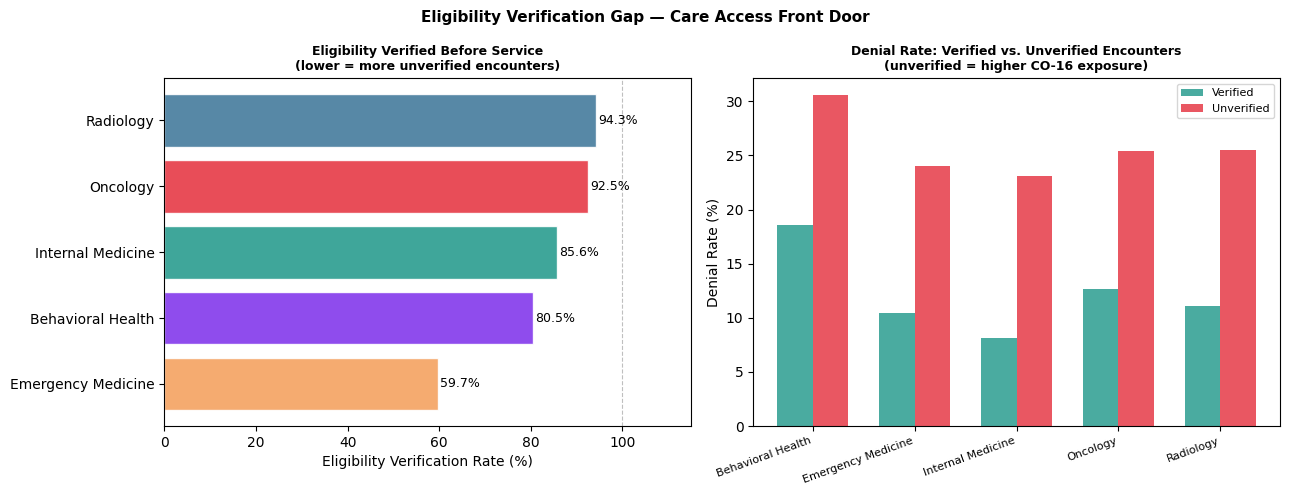

In [10]:


# ── ANALYSIS A: ELIGIBILITY VERIFICATION GAP ─────────────────────────────────
 
# Part 1: Verification rate by specialty
verify_rate = con.execute("""
    SELECT
        p.specialty,
        COUNT(ec.encounter_id)                                                AS total_encounters,
        SUM(CASE WHEN ec.eligibility_verified_flag = TRUE  THEN 1 ELSE 0 END) AS verified,
        SUM(CASE WHEN ec.eligibility_verified_flag = FALSE THEN 1 ELSE 0 END) AS unverified,
        ROUND(100.0 * SUM(CASE WHEN ec.eligibility_verified_flag = TRUE THEN 1 ELSE 0 END)
              / NULLIF(COUNT(ec.encounter_id), 0), 1)                         AS verify_rate_pct
    FROM encounter_context ec
    JOIN claim_header ch ON ec.claim_id = ch.claim_id
    JOIN provider p      ON ch.provider_id = p.provider_id
    GROUP BY p.specialty
    ORDER BY verify_rate_pct ASC
""").df()
 
# Part 2: Denial rate by specialty × eligibility status
verify_vs_denial = con.execute("""
    SELECT
        p.specialty,
        ec.eligibility_verified_flag,
        COUNT(r.remittance_id)                                                AS total_lines,
        ROUND(100.0 * SUM(CASE WHEN r.paid_amount = 0
                               AND r.carc_code NOT IN ('CO-45', 'PR-1')
                               THEN 1 ELSE 0 END)
              / NULLIF(COUNT(r.remittance_id), 0), 1)                         AS denial_rate_pct
    FROM encounter_context ec
    JOIN claim_header ch  ON ec.claim_id = ch.claim_id
    JOIN remittance_835 r ON ch.claim_id = r.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    GROUP BY p.specialty, ec.eligibility_verified_flag
    ORDER BY p.specialty, ec.eligibility_verified_flag
""").df()
 
print("Eligibility Verification Rate by Specialty\n")
print(verify_rate.to_string(index=False))
print("\nDenial Rate by Specialty × Eligibility Status\n")
print(verify_vs_denial.to_string(index=False))
 
# Visualization: side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
 
# Left: verification rate by specialty
colors = [SEGMENT_COLORS.get(s, "#adb5bd") for s in verify_rate["specialty"]]
bars = ax1.barh(verify_rate["specialty"], verify_rate["verify_rate_pct"],
                color=colors, edgecolor="white", alpha=0.9)
ax1.axvline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
for bar, val in zip(bars, verify_rate["verify_rate_pct"]):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9)
ax1.set_xlabel("Eligibility Verification Rate (%)")
ax1.set_title("Eligibility Verified Before Service\n(lower = more unverified encounters)",
              fontweight="bold", fontsize=9)
ax1.set_xlim(0, 115)
 
# Right: denial rate for verified vs unverified by specialty
pivot_vd = verify_vs_denial.pivot_table(
    index="specialty",
    columns="eligibility_verified_flag",
    values="denial_rate_pct"
).fillna(0)
pivot_vd = pivot_vd.rename(columns={True: "Verified", False: "Unverified"})
 
x = np.arange(len(pivot_vd))
width = 0.35
if "Verified" in pivot_vd.columns:
    ax2.bar(x - width/2, pivot_vd["Verified"], width,
            label="Verified", color="#2a9d8f", alpha=0.85)
if "Unverified" in pivot_vd.columns:
    ax2.bar(x + width/2, pivot_vd["Unverified"], width,
            label="Unverified", color="#e63946", alpha=0.85)
 
ax2.set_xticks(x)
ax2.set_xticklabels(pivot_vd.index, rotation=20, ha="right", fontsize=8)
ax2.set_ylabel("Denial Rate (%)")
ax2.set_title("Denial Rate: Verified vs. Unverified Encounters\n(unverified = higher CO-16 exposure)",
              fontweight="bold", fontsize=9)
ax2.legend(fontsize=8)
 
plt.suptitle("Eligibility Verification Gap — Care Access Front Door",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

Auth Engagement Taxonomy by Specialty

         specialty  total_encounters  auth_proactive  auth_retroactive  auth_not_obtained  auth_not_required
         Radiology              4936          1680.0             490.0             1004.0             1762.0
          Oncology              4928          2193.0             387.0              862.0             1486.0
Emergency Medicine              5020            10.0               0.0                1.0             5009.0
 Behavioral Health              4987             8.0               0.0                0.0             4979.0
 Internal Medicine              5129             8.0               0.0                0.0             5121.0


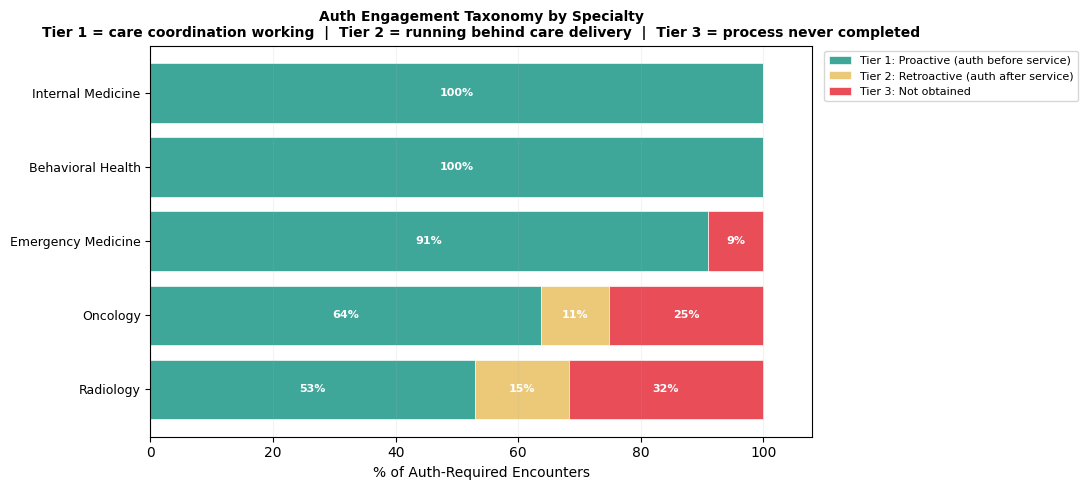

In [9]:
# AUTH ENGAGEMENT TAXONOMY 
# Three-tier spectrum from proactive coordination to complete process failure.
#
# NOTE ON DATA DESIGN:
# In this dataset, auth_request_date is only populated when auth was obtained.
# When auth was not obtained, auth_request_date = NULL.
# This means "not obtained" cases cannot be split into
# "never requested" vs. "requested but denied/expired" —
# both would appear as NULL in our model.
# In production data, this field would enable that deeper split,
# distinguishing structural gaps (no process) from executional failures
# (process engaged but broke down).
 
auth_taxonomy = con.execute("""
    SELECT
        p.specialty,
        COUNT(ec.encounter_id)                                                     AS total_encounters,
        -- Tier 1: Auth required + obtained proactively (before or on service date)
        SUM(CASE WHEN ec.prior_auth_required = TRUE
                  AND ec.prior_auth_obtained = TRUE
                  AND ec.auth_request_date IS NOT NULL
                  AND ec.auth_request_date <= ec.date_of_service
                 THEN 1 ELSE 0 END)                                                AS auth_proactive,
        -- Tier 2: Auth required + obtained retroactively (after service date)
        SUM(CASE WHEN ec.prior_auth_required = TRUE
                  AND ec.prior_auth_obtained = TRUE
                  AND ec.auth_request_date > ec.date_of_service
                 THEN 1 ELSE 0 END)                                                AS auth_retroactive,
        -- Tier 3: Auth required but process never completed
        SUM(CASE WHEN ec.prior_auth_required = TRUE
                  AND (ec.prior_auth_obtained = FALSE
                       OR ec.prior_auth_obtained IS NULL)
                 THEN 1 ELSE 0 END)                                                AS auth_not_obtained,
        -- Context: auth not required for this encounter
        SUM(CASE WHEN ec.prior_auth_required = FALSE
                  OR ec.prior_auth_required IS NULL
                 THEN 1 ELSE 0 END)                                                AS auth_not_required
    FROM encounter_context ec
    JOIN claim_header ch ON ec.claim_id = ch.claim_id
    JOIN provider p      ON ch.provider_id = p.provider_id
    GROUP BY p.specialty
    ORDER BY auth_not_obtained DESC
""").df()
 
print("Auth Engagement Taxonomy by Specialty\n")
print(auth_taxonomy.to_string(index=False))
 
# Compute % of auth-required encounters in each tier
auth_req = auth_taxonomy[["specialty", "auth_proactive",
                           "auth_retroactive", "auth_not_obtained"]].copy()
auth_req["total_auth_required"] = (
    auth_req["auth_proactive"] +
    auth_req["auth_retroactive"] +
    auth_req["auth_not_obtained"]
)
for col in ["auth_proactive", "auth_retroactive", "auth_not_obtained"]:
    auth_req[col + "_pct"] = (
        auth_req[col] / auth_req["total_auth_required"].replace(0, 1) * 100
    ).round(1)
 
# Filter to specialties that have any auth-required encounters
auth_plot = auth_req[auth_req["total_auth_required"] > 0].set_index("specialty")
 
fig, ax = plt.subplots(figsize=(11, 5))
y = range(len(auth_plot))
 
# Stack three tiers
left = np.zeros(len(auth_plot))
tier_config = [
    ("auth_proactive_pct",    "#2a9d8f",  "Tier 1: Proactive (auth before service)"),
    ("auth_retroactive_pct",  "#e9c46a",  "Tier 2: Retroactive (auth after service)"),
    ("auth_not_obtained_pct", "#e63946",  "Tier 3: Not obtained"),
]
for col, color, label in tier_config:
    vals = auth_plot[col].values
    ax.barh(list(y), vals, left=left, color=color,
            edgecolor="white", linewidth=0.5, alpha=0.9, label=label)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 6:
            ax.text(l + v/2, i, f"{v:.0f}%",
                    ha="center", va="center", fontsize=8,
                    color="white", fontweight="bold")
    left += vals
 
ax.set_yticks(list(y))
ax.set_yticklabels(auth_plot.index, fontsize=9)
ax.set_xlabel("% of Auth-Required Encounters")
ax.set_title(
    "Auth Engagement Taxonomy by Specialty\n"
    "Tier 1 = care coordination working  |  "
    "Tier 2 = running behind care delivery  |  "
    "Tier 3 = process never completed",
    fontsize=10, fontweight="bold"
)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_xlim(0, 108)
ax.grid(axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

#### What this tells us
##### The three tiers represent different levels of care coordination maturity:
##### **Tier 1 — Proactive:** The auth workflow is running ahead of care delivery.
###### Care coordinators are embedded in the ordering process. This is what functional care coordination looks like.
##### **Tier 2 — Retroactive:** Auth was eventually obtained, but after the service date.
###### The care coordination process exists but is running behind the clinical workflow.
###### These encounters didn't generate CO-57 denials in this period — but they represent process fragility. If a payer tightens retroactive auth policy,
###### Tier 2 encounters convert to denials overnight without any change in clinical behavior.

##### **Tier 3 — Not obtained:** Auth was required but never completed.
###### In production data, this tier can be further split into:
###### "never requested" (structural gap — no care coordination process exists)
###### vs. "requested but denied/expired" (executional gap — process engaged but failed).
###### That split identifies whether the intervention is a model change or a process improvement.

#### For an ACO medical director: Tier 2 + Tier 3 together define the care coordination gap.
###### Tier 2 is today's fragility. Tier 3 is today's denial source.